# Image Classification on Oxford 102 Flowers: ResNet vs EfficientNet vs ViT




## 1. Setup & Installs

In [1]:
# Uncomment if running in a fresh environment (e.g. Colab)
# !pip install -q torch torchvision scikit-learn matplotlib seaborn tqdm pandas


In [2]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms
from torchvision.models import (
    resnet18, ResNet18_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
    vit_b_16, ViT_B_16_Weights,
)

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## 2. Load Oxford 102 Flowers

`torchvision.datasets.Flowers102` downloads the dataset automatically
(~330 MB) and exposes the official `"train"`, `"val"`, and `"test"` splits.
Class labels are 0-indexed integers; a small mapping to human-readable
flower names is included below for nicer plots and reports.


In [3]:
DATA_ROOT = "./data"
os.makedirs(DATA_ROOT, exist_ok=True)

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = datasets.Flowers102(root=DATA_ROOT, split="train", download=True, transform=train_transform)
val_ds = datasets.Flowers102(root=DATA_ROOT, split="val", download=True, transform=eval_transform)
test_ds = datasets.Flowers102(root=DATA_ROOT, split="test", download=True, transform=eval_transform)

num_classes = 102
print(f"Number of classes: {num_classes}")
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")


Number of classes: 102
Train: 1020 | Val: 1020 | Test: 6149


In [4]:
# Human-readable flower names (standard 102-category list, index-aligned with the dataset labels)
FLOWER_NAMES = [
    "pink primrose","hard-leaved pocket orchid","canterbury bells","sweet pea","english marigold",
    "tiger lily","moon orchid","bird of paradise","monkshood","globe thistle","snapdragon",
    "colt's foot","king protea","spear thistle","yellow iris","globe-flower","purple coneflower",
    "peruvian lily","balloon flower","giant white arum lily","fire lily","pincushion flower",
    "fritillary","red ginger","grape hyacinth","corn poppy","prince of wales feathers",
    "stemless gentian","artichoke","sweet william","carnation","garden phlox","love in the mist",
    "mexican aster","alpine sea holly","ruby-lipped cattleya","cape flower","great masterwort",
    "siam tulip","lenten rose","barbeton daisy","daffodil","sword lily","poinsettia",
    "bolero deep blue","wallflower","marigold","buttercup","oxeye daisy","common dandelion",
    "petunia","wild pansy","primula","sunflower","pelargonium","bishop of llandaff","gaura",
    "geranium","orange dahlia","pink-yellow dahlia","cautleya spicata","japanese anemone",
    "black-eyed susan","silverbush","californian poppy","osteospermum","spring crocus",
    "bearded iris","windflower","tree poppy","gazania","azalea","water lily","rose",
    "thorn apple","morning glory","passion flower","lotus","toad lily","anthurium",
    "frangipani","clematis","hibiscus","columbine","desert-rose","tree mallow","magnolia",
    "cyclamen","watercress","canna lily","hippeastrum","bee balm","air plant","foxglove",
    "bougainvillea","camellia","mallow","mexican petunia","bromelia","blanket flower",
    "trumpet creeper","blackberry lily",
]
class_names = FLOWER_NAMES  # index i corresponds to label i
print("Example classes:", class_names[:5])


Example classes: ['pink primrose', 'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea', 'english marigold']


In [5]:
BATCH_SIZE = 128
NUM_WORKERS = 0

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)


## 3. Model Builders

Each model is loaded with ImageNet-pretrained weights and its final
classification layer is replaced to output `num_classes` (102) logits.


In [6]:
def build_model(name: str, num_classes: int) -> nn.Module:
    name = name.lower()

    if name == "resnet18":
        weights = ResNet18_Weights.DEFAULT
        model = resnet18(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    elif name == "efficientnet_b0":
        weights = EfficientNet_B0_Weights.DEFAULT
        model = efficientnet_b0(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    elif name == "vit_b_16":
        weights = ViT_B_16_Weights.DEFAULT
        model = vit_b_16(weights=weights)
        in_features = model.heads.head.in_features
        model.heads.head = nn.Linear(in_features, num_classes)

    else:
        raise ValueError(f"Unknown model name: {name}")

    return model.to(device)


## 4. Training & Evaluation Utilities

`train_model` fine-tunes for a given number of epochs and tracks the best
validation accuracy checkpoint. `evaluate_model` computes accuracy,
precision/recall/F1 (macro & weighted), a full classification report,
and a confusion matrix on the test set.


In [7]:
def train_model(model, train_loader, val_loader, epochs=15, lr=1e-4, model_name="model"):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_acc = 0.0
    best_state = copy.deepcopy(model.state_dict())
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        # ---- Train ----
        model.train()
        running_loss = 0.0
        for imgs, labels in tqdm(train_loader, desc=f"[{model_name}] Epoch {epoch+1}/{epochs} - train"):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        # ---- Validate ----
        model.eval()
        val_loss = 0.0
        correct = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = correct / len(val_loader.dataset)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"[{model_name}] Epoch {epoch+1}/{epochs} "
              f"- train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return model, history


def evaluate_model(model, test_loader, class_names, model_name="model"):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in tqdm(test_loader, desc=f"[{model_name}] evaluating"):
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0)
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="weighted", zero_division=0)

    print(f"\n=== {model_name} Test Metrics ===")
    print(f"Accuracy:            {acc:.4f}")
    print(f"Precision (macro):   {precision_macro:.4f}")
    print(f"Recall (macro):      {recall_macro:.4f}")
    print(f"F1-score (macro):    {f1_macro:.4f}")
    print(f"Precision (weighted):{precision_weighted:.4f}")
    print(f"Recall (weighted):   {recall_weighted:.4f}")
    print(f"F1-score (weighted): {f1_weighted:.4f}\n")

    report = classification_report(
        all_labels, all_preds, target_names=class_names, zero_division=0
    )
    print(report)

    metrics = {
        "model": model_name,
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "y_true": all_labels,
        "y_pred": all_preds,
        "report": report,
    }
    return metrics


def plot_confusion_matrix(y_true, y_pred, class_names, model_name="model", max_labels_shown=30):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    # With 102 classes a full label set is unreadable; show ticks only if class count is small
    show_labels = len(class_names) <= max_labels_shown
    sns.heatmap(cm, cmap="viridis",
                xticklabels=class_names if show_labels else False,
                yticklabels=class_names if show_labels else False)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


def plot_training_curves(history, model_name="model"):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs, history["val_loss"], label="Val Loss")
    axes[0].set_title(f"{model_name} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(epochs, history["val_acc"], label="Val Accuracy", color="green")
    axes[1].set_title(f"{model_name} - Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


## 5. Training Configuration

The official Flowers102 train split has only **1,020 images** (10 per
class)

In [8]:
EPOCHS = 10
LR = 1e-4

all_results = {}   # model_name -> metrics dict
all_histories = {} # model_name -> training history


## 6. ResNet-18

In [23]:
resnet_model = build_model("resnet18", num_classes)
resnet_model, resnet_history = train_model(
    resnet_model, train_loader, val_loader, epochs=EPOCHS, lr=LR, model_name="ResNet18"
)
all_histories["ResNet18"] = resnet_history


[ResNet18] Epoch 1/10 - train:   0%|          | 0/8 [00:00<?, ?it/s]

[ResNet18] Epoch 1/10 - train_loss: 4.5771 - val_loss: 4.1738 - val_acc: 0.1000


[ResNet18] Epoch 2/10 - train:   0%|          | 0/8 [00:00<?, ?it/s]

[ResNet18] Epoch 2/10 - train_loss: 3.5546 - val_loss: 3.4885 - val_acc: 0.3598


[ResNet18] Epoch 3/10 - train:   0%|          | 0/8 [00:00<?, ?it/s]

...

[ResNet18] Epoch 8/10 - train_loss: 1.2875 - val_loss: 2.0454 - val_acc: 0.7833


[ResNet18] Epoch 9/10 - train:   0%|          | 0/8 [00:00<?, ?it/s]

[ResNet18] Epoch 9/10 - train_loss: 1.2309 - val_loss: 2.0279 - val_acc: 0.7892


[ResNet18] Epoch 10/10 - train:   0%|          | 0/8 [00:00<?, ?it/s]

[ResNet18] Epoch 10/10 - train_loss: 1.1958 - val_loss: 2.0273 - val_acc: 0.7912


[ResNet18] evaluating:   0%|          | 0/49 [00:00<?, ?it/s]


=== ResNet18 Test Metrics ===
Accuracy:            0.7624
Precision (macro):   0.7492
Recall (macro):      0.7851
F1-score (macro):    0.7426
Precision (weighted):0.7924
Recall (weighted):   0.7624
F1-score (weighted): 0.7527

                           precision    recall  f1-score   support

            pink primrose       0.76      0.65      0.70        20
hard-leaved pocket orchid       0.88      0.95      0.92        40
         canterbury bells       0.00      0.00      0.00        20
                sweet pea       0.38      0.50      0.43        36
         english marigold       0.79      0.58      0.67        45
               tiger lily       0.85      0.92      0.88        25
              moon orchid       0.61      0.85      0.71        20
         bird of paradise       0.98      1.00      0.99        65
                monkshood       0.45      0.88      0.60        26
            globe thistle       0.88      0.92      0.90        25
               snapdragon       0.

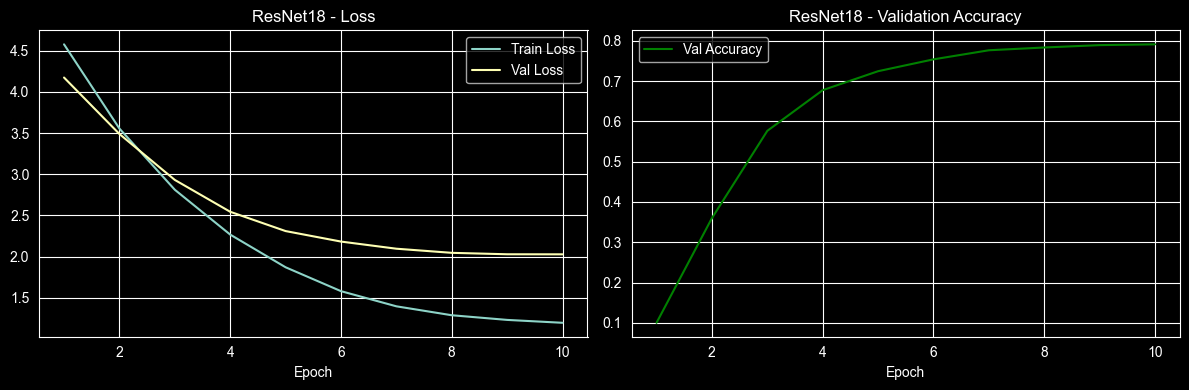

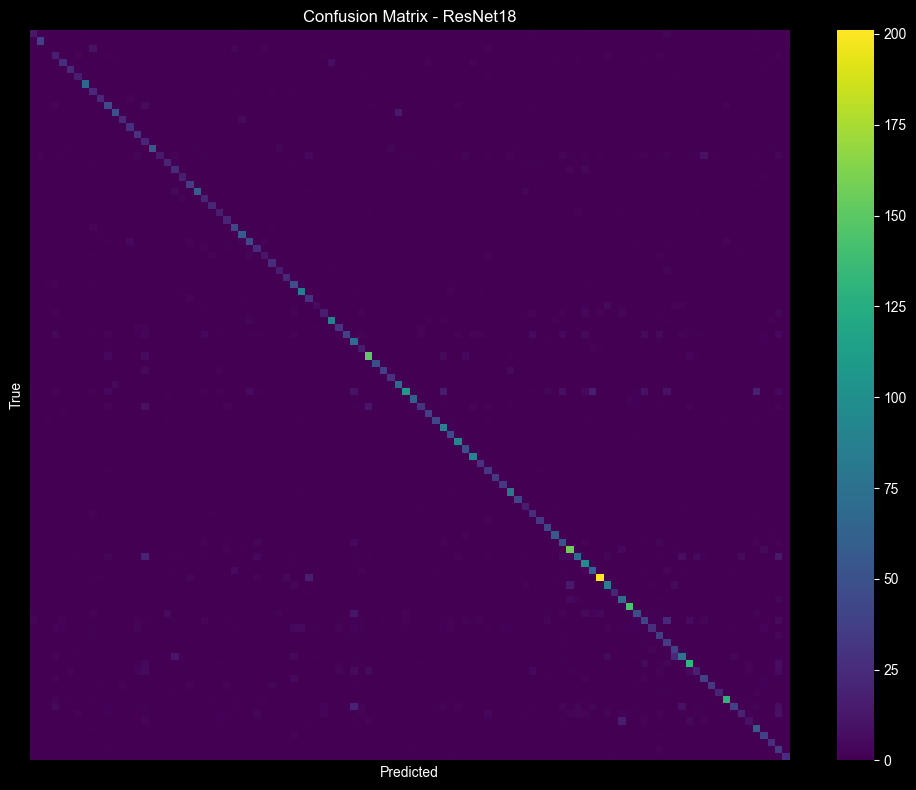

In [24]:
resnet_metrics = evaluate_model(resnet_model, test_loader, class_names, model_name="ResNet18")
all_results["ResNet18"] = resnet_metrics
plot_training_curves(resnet_history, "ResNet18")
plot_confusion_matrix(resnet_metrics["y_true"], resnet_metrics["y_pred"], class_names, "ResNet18")


## 7. EfficientNet-B0

In [9]:
effnet_model = build_model("efficientnet_b0", num_classes)
effnet_model, effnet_history = train_model(
    effnet_model, train_loader, val_loader, epochs=EPOCHS, lr=LR, model_name="EfficientNet-B0"
)
all_histories["EfficientNet-B0"] = effnet_history


[EfficientNet-B0] Epoch 1/10 - train:   0%|          | 0/8 [00:00<?, ?it/s]

[EfficientNet-B0] Epoch 1/10 - train_loss: 4.6014 - val_loss: 4.5286 - val_acc: 0.0451


[EfficientNet-B0] Epoch 2/10 - train:   0%|          | 0/8 [00:00<?, ?it/s]

[EfficientNet-B0] Epoch 2/10 - train_loss: 4.4163 - val_loss: 4.3697 - val_acc: 0.1539


[EfficientNet-B0] Epoch 3/10 - train:   0%|          | 0/8 [00:00<?, ?it/s]

...

[EfficientNet-B0] Epoch 8/10 - train_loss: 3.4892 - val_loss: 3.6977 - val_acc: 0.5294


[EfficientNet-B0] Epoch 9/10 - train:   0%|          | 0/8 [00:00<?, ?it/s]

[EfficientNet-B0] Epoch 9/10 - train_loss: 3.4337 - val_loss: 3.6911 - val_acc: 0.5304


[EfficientNet-B0] Epoch 10/10 - train:   0%|          | 0/8 [00:00<?, ?it/s]

[EfficientNet-B0] Epoch 10/10 - train_loss: 3.4144 - val_loss: 3.6952 - val_acc: 0.5392


[EfficientNet-B0] evaluating:   0%|          | 0/49 [00:00<?, ?it/s]


=== EfficientNet-B0 Test Metrics ===
Accuracy:            0.5001
Precision (macro):   0.5018
Recall (macro):      0.5285
F1-score (macro):    0.4657
Precision (weighted):0.5780
Recall (weighted):   0.5001
F1-score (weighted): 0.4811

                           precision    recall  f1-score   support

            pink primrose       0.31      0.45      0.37        20
hard-leaved pocket orchid       0.97      0.82      0.89        40
         canterbury bells       0.08      0.25      0.12        20
                sweet pea       0.00      0.00      0.00        36
         english marigold       0.55      0.60      0.57        45
               tiger lily       0.48      0.96      0.64        25
              moon orchid       0.22      0.50      0.31        20
         bird of paradise       0.78      0.92      0.85        65
                monkshood       0.27      0.42      0.33        26
            globe thistle       0.86      0.96      0.91        25
               snapdragon  

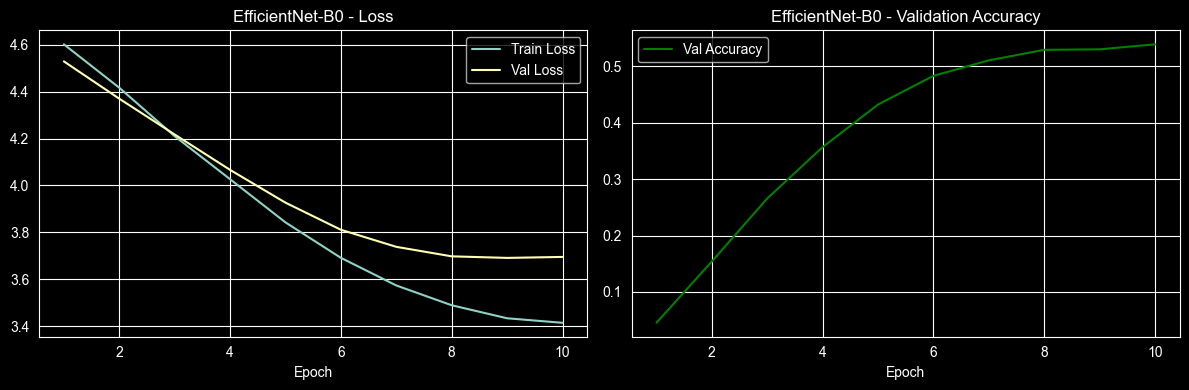

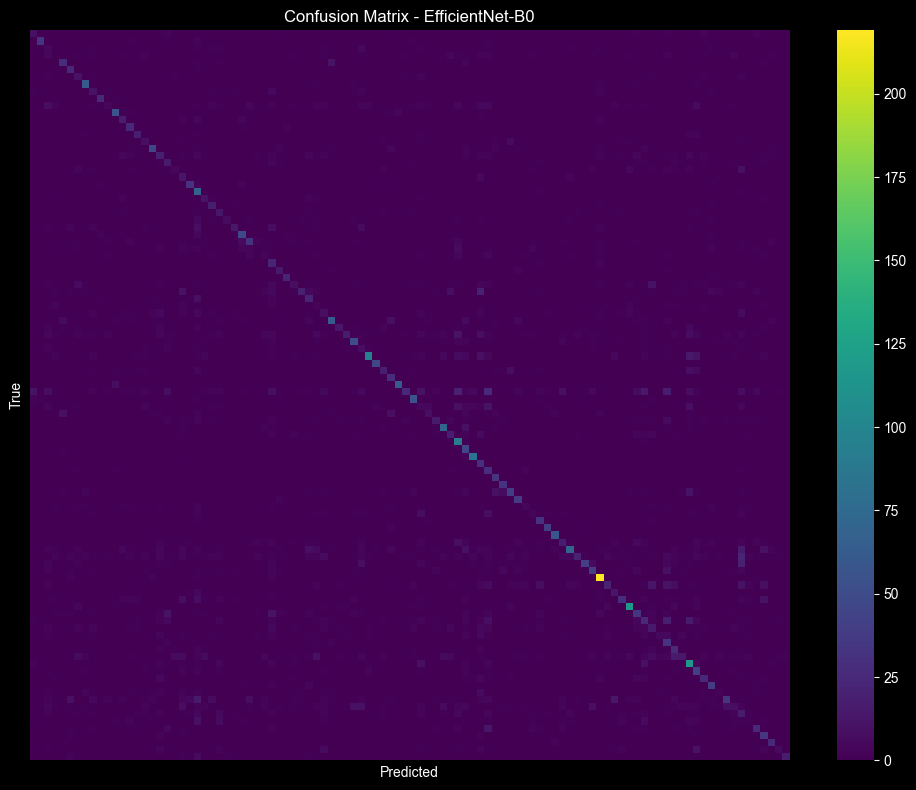

In [10]:
effnet_metrics = evaluate_model(effnet_model, test_loader, class_names, model_name="EfficientNet-B0")
all_results["EfficientNet-B0"] = effnet_metrics
plot_training_curves(effnet_history, "EfficientNet-B0")
plot_confusion_matrix(effnet_metrics["y_true"], effnet_metrics["y_pred"], class_names, "EfficientNet-B0")


## 8. Vision Transformer (ViT-B/16)

In [ ]:
vit_model = build_model("vit_b_16", num_classes)
vit_model, vit_history = train_model(
    vit_model, train_loader, val_loader, epochs=EPOCHS, lr=LR, model_name="ViT-B/16"
)
all_histories["ViT-B/16"] = vit_history


In [ ]:
vit_metrics = evaluate_model(vit_model, test_loader, class_names, model_name="ViT-B/16")
all_results["ViT-B/16"] = vit_metrics
plot_training_curves(vit_history, "ViT-B/16")
plot_confusion_matrix(vit_metrics["y_true"], vit_metrics["y_pred"], class_names, "ViT-B/16")


## 9. Model Comparison

Side-by-side comparison of all metrics across the three architectures.


In [ ]:
comparison_df = pd.DataFrame([
    {
        "Model": name,
        "Accuracy": m["accuracy"],
        "Precision (macro)": m["precision_macro"],
        "Recall (macro)": m["recall_macro"],
        "F1 (macro)": m["f1_macro"],
        "Precision (weighted)": m["precision_weighted"],
        "Recall (weighted)": m["recall_weighted"],
        "F1 (weighted)": m["f1_weighted"],
    }
    for name, m in all_results.items()
])

comparison_df = comparison_df.set_index("Model").round(4)
comparison_df


In [ ]:
# Bar chart comparing macro F1 / accuracy across models
fig, ax = plt.subplots(figsize=(8, 5))
comparison_df[["Accuracy", "F1 (macro)", "F1 (weighted)"]].plot(kind="bar", ax=ax)
ax.set_ylabel("Score")
ax.set_title("Model Comparison on Oxford 102 Flowers")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
